In [1]:
import ctadata
from astropy.io import fits
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord

In [2]:
!cta-data start-agent

/layers/paketo-buildpacks_conda-env-update/conda-env/bin/oidc-agent
/layers/paketo-buildpacks_conda-env-update/conda-env/bin/davix-ls
/layers/paketo-buildpacks_conda-env-update/conda-env/bin/davix-get
/layers/paketo-buildpacks_conda-env-update/conda-env/bin/davix-put
success


In [3]:
head_data_path = "../cta_dc_data/"
CRAB_data_path = head_data_path + "CRAB/"

In [4]:
!mkdir -p {CRAB_data_path}

In [5]:
ctadata.fetch_and_save_file(f'pnfs/cta.cscs.ch/cta/sdc-internal-data/obs-index.fits.gz')
!mv obs-index.fits.gz {head_data_path}

<SkyCoord (ICRS): (ra, dec) in deg
    (83.6324, 22.0174)>

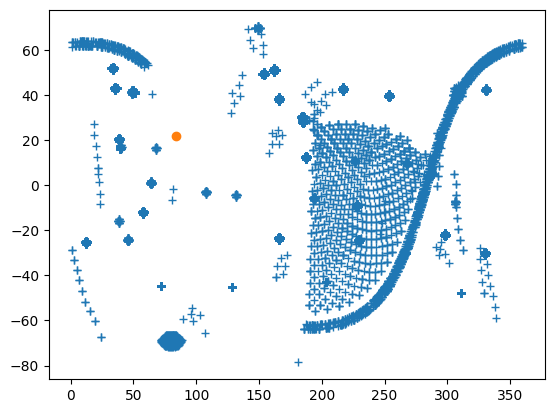

In [24]:
obs_list = fits.open(head_data_path + "obs-index.fits.gz")[1]
obs_ra = np.array(obs_list.data["RA_PNT"])
obs_dec = np.array(obs_list.data["DEC_PNT"])
obs_coord = SkyCoord(ra=obs_ra*u.deg, dec=obs_dec*u.deg, frame='icrs')

CRAB_coord = SkyCoord.from_name("Crab")

plt.plot(obs_ra, obs_dec, "+")
plt.plot(CRAB_coord.ra, CRAB_coord.dec, "o")
CRAB_coord

In [26]:
max_separation = 2
CRAB_obs_mask = obs_coord.separation(CRAB_coord).degree < max_separation
print("Obs:")
print(sum(CRAB_obs_mask))

Obs:
0


In [18]:
irf_files = set()

for file in obs_list.data["IRF_FILENAME"][CRAB_obs_mask]:
    irf_files.add(file)
for file in irf_files:
    print(str(file))

In [19]:
for obs_id in obs_list.data["OBS_ID"][CRAB_obs_mask]:
    ctadata.fetch_and_save_file(f'pnfs/cta.cscs.ch/cta/sdc-internal-data/products_SDC/Events/North/events_{obs_id}.fits')
    !mv events_{obs_id}.fits {CRAB_data_path}